<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">15. MPI-GE Global Mean Temperature Context</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">Computes area-weighted global mean surface air temperature (GMT) for Hist-ALL, Hist-NAT, and SSP2-4.5, providing forcing-level context for the three scenarios used throughout this dissertation, independent of the regional Rx5day analysis.</p>
</div>

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

HIST_PATH = '/data/oacd/smiles/MPI/historical/tas_day/'
NAT_PATH = '/data/oacd/smiles/MPI/hist-nat/tas_day/'
SSP_PATH = '/data/oacd/smiles/MPI/ssp245/tas_day/'
MEMBERS = [f'r{i}i1p1f1' for i in range(1, 31)]

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
NAT_PATCH_PATH = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/raw/mpi_tas_patch/'

In [3]:
import glob
files_nat = sorted(glob.glob(NAT_PATH + '*r1i1p1f1*.nc'))
print(f"Found {len(files_nat)} files for r1i1p1f1")
for f in files_nat:
    print(f)

Found 9 files for r1i1p1f1
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_18500101-18691231.nc
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_18700101-18891231.nc
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_18900101-19091231.nc
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_19100101-19291231.nc
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_19300101-19491231.nc
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_19500101-19691231.nc
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_19700101-19891231.nc
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_19900101-20091231.nc
/data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r1i1p1f1_gn_20100101-20141231.nc


In [4]:
import os
all_nc_files = sorted(glob.glob(NAT_PATH + '*.nc'))
print(f"Total .nc files in NAT_PATH: {len(all_nc_files)}")

# Check for zero-byte or suspiciously small files
for f in all_nc_files:
    size = os.path.getsize(f)
    if size < 1000:  # anything under 1KB is almost certainly broken/incomplete
        print(f"SUSPICIOUS (tiny file): {f} - {size} bytes")

Total .nc files in NAT_PATH: 270
SUSPICIOUS (tiny file): /data/oacd/smiles/MPI/hist-nat/tas_day/tas_day_MPI-ESM1-2-LR_hist-nat_r29i1p1f1_gn_19500101-19691231.nc - 0 bytes


In [5]:
def compute_annual_gmt(member, base_path):
    """Area-weighted (cos-latitude) global annual mean tas for one member.
       Falls back to patch directory for known corrupted files (r29i1p1f1, hist-nat)."""
    files = sorted(glob.glob(base_path + f'*{member}*.nc'))
    files = [f for f in files if os.path.getsize(f) > 0]  # drop any 0-byte files

    if base_path == NAT_PATH and member == 'r29i1p1f1':
        patch_file = NAT_PATCH_PATH + 'tas_day_MPI-ESM1-2-LR_hist-nat_r29i1p1f1_gn_19500101-19691231.nc'
        if os.path.exists(patch_file):
            files.append(patch_file)
            files = sorted(files)

    if len(files) == 0:
        raise FileNotFoundError(f'No valid files for {member} in {base_path}')

    ds = xr.open_mfdataset(files, combine='by_coords', chunks={'time': 365})
    tas = ds['tas']

    weights = np.cos(np.deg2rad(tas.lat))
    weights.name = 'weights'
    tas_weighted = tas.weighted(weights)
    global_mean_daily = tas_weighted.mean(dim=['lat', 'lon'])

    annual_mean = global_mean_daily.groupby('time.year').mean(dim='time') - 273.15
    return annual_mean.compute()

# Test on one member first before running all 30
test_gmt = compute_annual_gmt('r1i1p1f1', HIST_PATH)
print(test_gmt)
print(f"\nMean GMT across record: {float(test_gmt.mean()):.2f} C")

<xarray.DataArray 'tas' (year: 165)> Size: 1kB
array([13.48521779, 13.46783365, 13.46984005, 13.82339895, 13.68674849,
       13.54301016, 13.4736497 , 13.55926091, 13.54465026, 13.59580404,
       13.59856163, 13.69875539, 13.50271946, 13.53210749, 13.74144064,
       13.69359674, 13.53876879, 13.58544038, 13.49532523, 13.51569812,
       13.68381367, 13.61145207, 13.56516805, 13.55372467, 13.44134618,
       13.36877413, 13.38202133, 13.46094096, 13.51297787, 13.60449774,
       13.50868424, 13.46446848, 13.44449913, 13.52301591, 13.22180429,
       13.27486398, 13.40321841, 13.38402548, 13.5046939 , 13.7008598 ,
       13.67538483, 13.4360666 , 13.37736464, 13.57769257, 13.47354827,
       13.52730519, 13.59100463, 13.69696144, 13.51848225, 13.45466266,
       13.46060067, 13.58942835, 13.58449122, 13.30151046, 13.49814034,
       13.65407584, 13.54210866, 13.50120298, 13.44489669, 13.38659849,
       13.5391538 , 13.60409373, 13.53270055, 13.62422251, 13.70642955,
       13.6319409

In [6]:
def build_all_members_gmt(base_path, label):
    print(f'Computing GMT: {label}...')
    all_gmt = []
    for m in MEMBERS:
        gmt = compute_annual_gmt(m, base_path)
        all_gmt.append(gmt)
        print(f'  {m} done')
    stacked = xr.concat(all_gmt, dim='member').assign_coords(member=MEMBERS)
    return stacked

gmt_ant = build_all_members_gmt(HIST_PATH, 'Hist-ALL')
gmt_nat = build_all_members_gmt(NAT_PATH, 'Hist-NAT')
gmt_ssp = build_all_members_gmt(SSP_PATH, 'SSP2-4.5')

print('\nShapes:', dict(gmt_ant.sizes), dict(gmt_nat.sizes), dict(gmt_ssp.sizes))

Computing GMT: Hist-ALL...
  r1i1p1f1 done
  r2i1p1f1 done
  r3i1p1f1 done
  r4i1p1f1 done
  r5i1p1f1 done
  r6i1p1f1 done
  r7i1p1f1 done
  r8i1p1f1 done
  r9i1p1f1 done
  r10i1p1f1 done
  r11i1p1f1 done
  r12i1p1f1 done
  r13i1p1f1 done
  r14i1p1f1 done
  r15i1p1f1 done
  r16i1p1f1 done
  r17i1p1f1 done
  r18i1p1f1 done
  r19i1p1f1 done
  r20i1p1f1 done
  r21i1p1f1 done
  r22i1p1f1 done
  r23i1p1f1 done
  r24i1p1f1 done
  r25i1p1f1 done
  r26i1p1f1 done
  r27i1p1f1 done
  r28i1p1f1 done
  r29i1p1f1 done
  r30i1p1f1 done
Computing GMT: Hist-NAT...
  r1i1p1f1 done
  r2i1p1f1 done
  r3i1p1f1 done
  r4i1p1f1 done
  r5i1p1f1 done
  r6i1p1f1 done
  r7i1p1f1 done
  r8i1p1f1 done
  r9i1p1f1 done
  r10i1p1f1 done
  r11i1p1f1 done
  r12i1p1f1 done
  r13i1p1f1 done
  r14i1p1f1 done
  r15i1p1f1 done
  r16i1p1f1 done
  r17i1p1f1 done
  r18i1p1f1 done
  r19i1p1f1 done
  r20i1p1f1 done
  r21i1p1f1 done
  r22i1p1f1 done
  r23i1p1f1 done
  r24i1p1f1 done
  r25i1p1f1 done
  r26i1p1f1 done
  r27i1p1f1 

In [7]:
gmt_ant.to_dataset(name='gmt').to_netcdf(OUTPUT_DIR + 'gmt_ant_allmembers.nc')
gmt_nat.to_dataset(name='gmt').to_netcdf(OUTPUT_DIR + 'gmt_nat_allmembers.nc')
gmt_ssp.to_dataset(name='gmt').to_netcdf(OUTPUT_DIR + 'gmt_ssp_allmembers.nc')

print("Saved all three GMT files")

Saved all three GMT files


In [8]:
gmt_ant = xr.open_dataset(OUTPUT_DIR + 'gmt_ant_allmembers.nc')['gmt']
gmt_nat = xr.open_dataset(OUTPUT_DIR + 'gmt_nat_allmembers.nc')['gmt']
gmt_ssp = xr.open_dataset(OUTPUT_DIR + 'gmt_ssp_allmembers.nc')['gmt']

print('Loaded saved GMT files:', dict(gmt_ant.sizes), dict(gmt_nat.sizes), dict(gmt_ssp.sizes))

Loaded saved GMT files: {'member': 30, 'year': 165} {'member': 30, 'year': 165} {'member': 30, 'year': 86}


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Figure: Global Mean Temperature, Three Forcing Scenarios</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Ensemble-mean global mean surface air temperature (area-weighted) for Hist-NAT, Hist-ALL, and SSP2-4.5, with shaded bands showing the 10th-90th percentile range across 30 members. Provides forcing-level context for the three scenarios used throughout this dissertation.</p>
</div>

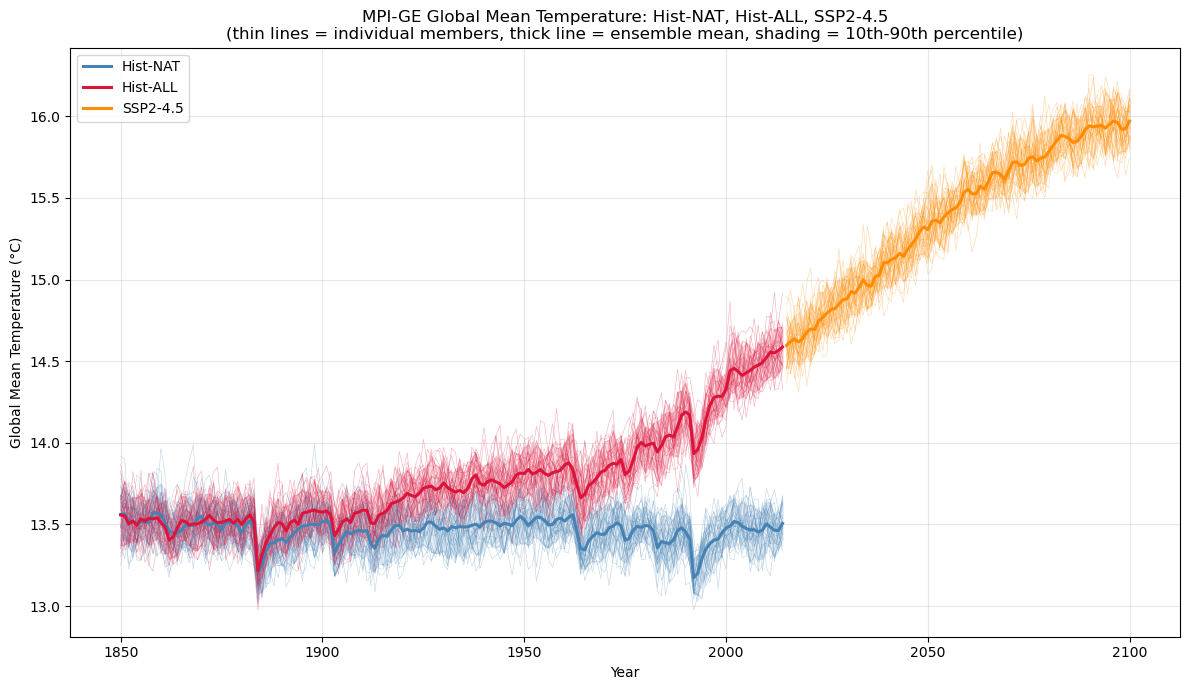

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))

scenarios = [
    (gmt_nat, 'Hist-NAT', 'steelblue'),
    (gmt_ant, 'Hist-ALL', 'crimson'),
    (gmt_ssp, 'SSP2-4.5', 'darkorange')
]

for gmt_data, label, color in scenarios:
    years = gmt_data.year.values
    ens_mean = gmt_data.mean(dim='member')
    p10 = gmt_data.quantile(0.10, dim='member')
    p90 = gmt_data.quantile(0.90, dim='member')

    # thin individual member traces
    for m in gmt_data.member.values:
        ax.plot(years, gmt_data.sel(member=m), color=color, linewidth=0.4, alpha=0.35, zorder=1)

    # transparent shaded band
    ax.fill_between(years, p10, p90, color=color, alpha=0.15, zorder=2)

    # thick ensemble mean on top
    ax.plot(years, ens_mean, color=color, linewidth=2.2, label=label, zorder=3)

ax.set_xlabel('Year')
ax.set_ylabel('Global Mean Temperature (°C)')
ax.set_title('MPI-GE Global Mean Temperature: Hist-NAT, Hist-ALL, SSP2-4.5\n(thin lines = individual members, thick line = ensemble mean, shading = 10th-90th percentile)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_gmt_timeseries_combined.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
def summarize_scenario(gmt_data, label):
    return pd.DataFrame({
        'year': gmt_data.year.values,
        'scenario': label,
        'gmt_mean_c': gmt_data.mean(dim='member').values,
        'gmt_p10_c': gmt_data.quantile(0.10, dim='member').values,
        'gmt_p90_c': gmt_data.quantile(0.90, dim='member').values,
    })

gmt_summary = pd.concat([
    summarize_scenario(gmt_nat, 'Hist-NAT'),
    summarize_scenario(gmt_ant, 'Hist-ALL'),
    summarize_scenario(gmt_ssp, 'SSP2-4.5'),
], ignore_index=True)

gmt_summary.to_csv(OUTPUT_DIR + 'gmt_summary_by_scenario.csv', index=False)
print(f"Saved gmt_summary_by_scenario.csv, {len(gmt_summary)} rows")
print(gmt_summary.head())

Saved gmt_summary_by_scenario.csv, 416 rows
   year  scenario  gmt_mean_c  gmt_p10_c  gmt_p90_c
0  1850  Hist-NAT   13.561741  13.384812  13.732924
1  1851  Hist-NAT   13.564815  13.423956  13.707854
2  1852  Hist-NAT   13.517128  13.360298  13.681181
3  1853  Hist-NAT   13.519822  13.329622  13.655166
4  1854  Hist-NAT   13.502304  13.390805  13.604276


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Summary</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Area-weighted global mean temperature confirms expected forcing separation: Hist-NAT shows no long-term trend (~13.3-13.5C throughout 1850-2014, with shared volcanic dips e.g. 1885, 1992), Hist-ALL diverges upward from ~1900-1920 onward reaching ~14.6C by 2014, and SSP2-4.5 continues warming to ~16C by 2100. Provides forcing-level context for the three scenarios used throughout the dissertation.</p>
</div>